# Latent Factor Mapping + Hierarchical Risk Parity
Replication Portfolio using Autoencoder Latent Factor Mapping and Hierarchical Risk Parity (HRP).

- **Train:** Jan 2020 – June 2025
- **Holdout Test:** July 2025 – Dec 2025

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform

np.random.seed(42)
torch.manual_seed(42)

## 1. Data Loading

In [2]:
data_dir = '../data'
constituents_dir = os.path.join(data_dir, 'sp500 constituents')
benchmark_path = os.path.join(data_dir, '^GSPC.csv')

def load_data():
    # Load Benchmark
    print("Loading benchmark data...")
    df_bench = pd.read_csv(benchmark_path)
    df_bench['Date'] = pd.to_datetime(df_bench['Date'])
    df_bench = df_bench.sort_values('Date').set_index('Date')
    df_bench = df_bench.loc[~df_bench.index.duplicated(keep='last')]
    benchmark_prices = df_bench[['Close']].rename(columns={'Close': '^GSPC'})
    
    # Load Constituents
    print("Loading constituents data...")
    all_files = glob.glob(os.path.join(constituents_dir, '*.csv'))
    
    stock_prices_list = []
    
    for file in all_files:
        ticker = os.path.splitext(os.path.basename(file))[0]

        df_stock = pd.read_csv(file)
        df_stock['Date'] = pd.to_datetime(df_stock['Date'])
        df_stock = df_stock.sort_values('Date').set_index('Date')
        df_stock = df_stock.loc[~df_stock.index.duplicated(keep='last')]
            
        # Use Adj Close if available, else Close
        if 'Adj Close' in df_stock.columns:
            price_col = 'Adj Close' 
        else:
            price_col = 'Close'
        df_stock = df_stock[[price_col]].rename(columns={price_col: ticker})
        stock_prices_list.append(df_stock)
            
    # Concatenate all series along the Date index
    df_stocks = pd.concat(stock_prices_list, axis=1)
    
    # Merge with benchmark
    df_all = benchmark_prices.join(df_stocks, how='outer')
    
    # Forward fill missing values to handle non-trading days differences
    df_all = df_all.ffill()
    
    # Drop rows before Jan 2020 if any
    df_all = df_all[df_all.index >= '2020-01-01']
    
    # Drop columns that have excessive missing values (> 5% missing after start)
    missing_pct = df_all.isnull().mean()
    dropped_cols = missing_pct[missing_pct > 0.05].index
    print(f"Dropping {len(dropped_cols)} stocks due to missing data (>5% missing).")
    df_all = df_all.drop(columns=dropped_cols)
    
    # Drop any remaining NaNs 
    df_all = df_all.dropna()
    
    print(f"Final dataset shape: {df_all.shape}")
    return df_all

df_prices = load_data()
df_prices.head()


Loading benchmark data...
Loading constituents data...
Dropping 24 stocks due to missing data (>5% missing).
Final dataset shape: (1492, 560)


,^GSPC,A,AAL,AAP,AAPL,ABBV,ABT,ACGL,ACN,ADBE,...,XEL,XOM,XRAY,XYL,XYZ,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-19,2409.389893,63.042397,10.29,76.012421,59.200542,55.706875,66.955215,25.731314,145.760696,307.510010,...,48.526421,26.432968,31.149555,60.207314,40.000000,56.204372,82.418640,185.070007,22.301153,97.001999
2020-03-20,2304.919922,63.713478,10.38,66.339561,55.442150,53.950867,61.113499,24.694834,137.888641,295.339996,...,42.367516,25.135504,29.117863,55.938820,38.090000,52.146164,79.496941,179.380005,20.934437,95.684357
2020-03-23,2237.399902,60.751183,10.25,69.407654,54.264336,50.564243,56.458073,22.117901,132.140991,307.269989,...,41.840324,24.145132,28.301638,52.903236,40.009998,50.745556,74.716759,170.720001,19.706852,87.835464
2020-03-24,2447.330078,64.231186,13.92,76.374931,59.708420,52.908218,62.632328,24.343002,144.243240,310.000000,...,45.229385,27.208378,29.996189,57.909611,46.310001,62.543079,86.357414,180.550003,20.607084,98.357521
2020-03-25,2475.560059,66.148529,15.39,79.902786,59.379501,53.237480,63.584976,24.457109,139.617554,305.910004,...,46.484608,28.628685,31.051954,59.646893,52.389999,65.425133,89.528824,186.229996,21.155401,102.575836


## 2. Data and Target

In [3]:
def compute_log_returns(df):
    return np.log(df / df.shift(1)).dropna()

df_returns = compute_log_returns(df_prices)

# Extract y and X
y = df_returns['^GSPC']
X = df_returns.drop(columns=['^GSPC'])

# Train: Jan 2020 - June 2025
# Holdout Test: July 2025 - Dec 2025
train_mask = (df_returns.index >= '2020-01-01') & (df_returns.index <= '2025-06-30')
test_mask = (df_returns.index >= '2025-07-01') & (df_returns.index <= '2025-12-31')

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(f"Training set: {X_train.shape[0]} days, {X_train.shape[1]} stocks")
print(f"Test set:     {X_test.shape[0]} days, {X_test.shape[1]} stocks")


Training set: 1326 days, 559 stocks
Test set:     128 days, 559 stocks


## 3. Latent Factor Extraction

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, k):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.Tanh(),
            nn.Linear(128, k)
        )
        self.decoder = nn.Sequential(
            nn.Linear(k, 128),
            nn.Tanh(),
            nn.Linear(128, input_dim)
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

def extract_latent_factors(X_, k, epochs=50, batch_size=32, lr=1e-3):
    # Standardize X
    X_mean = X_.mean()
    X_std = X_.std()
    X_norm = (X_ - X_mean) / X_std
    
    tensor_x = torch.FloatTensor(X_norm.values)
    dataset = TensorDataset(tensor_x)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = Autoencoder(input_dim=X_.shape[1], k=k)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    for epoch in range(epochs):
        for data in dataloader:
            batch = data[0]
            optimizer.zero_grad()
            decoded, _ = model(batch)
            loss = criterion(decoded, batch)
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        _, factors = model(tensor_x)
        
    factors_df = pd.DataFrame(factors.numpy(), index=X_.index, columns=[f"Factor_{i+1}" for i in range(k)])
    return factors_df


## 4. Stock Selection Via Factor Correlation

In [5]:
def select_stocks(X_, factors, M, k):
    selected = set()
    stocks_per_factor = max(1, M // k)
    
    # Absolute correlation between stocks and latent factors
    all_corrs = []
    for factor in factors.columns:
        corrs = X_.apply(lambda col: col.corr(factors[factor])).abs()
        all_corrs.append(corrs)
        top_factor_stocks = corrs.nlargest(stocks_per_factor).index.tolist()
        selected.update(top_factor_stocks)
        
    # Global top correlation ranker to fill up to M or reduce to M
    all_corrs_df = pd.DataFrame(all_corrs, index=factors.columns).T
    max_corrs = all_corrs_df.max(axis=1)
    
    best_stocks = max_corrs.loc[list(selected)].nlargest(M).index.tolist()
    
    if len(best_stocks) < M:
        extra_needed = M - len(best_stocks)
        remaining = set(X_.columns) - set(best_stocks)
        extra_stocks = max_corrs.loc[list(remaining)].nlargest(extra_needed).index.tolist()
        best_stocks.extend(extra_stocks)
        
    return best_stocks[:M]


## 5. Hierarchical Risk Parity

In [6]:
def get_inverse_variance_portfolio(cov):
    ivp = 1.0 / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

def get_cluster_var(cov, c_items):
    cov_ = cov.loc[c_items, c_items]
    ivp = get_inverse_variance_portfolio(cov_)
    cv = np.dot(np.dot(ivp, cov_), ivp)
    return cv

def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index
        j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0])
        sort_ix = sort_ix.sort_index()
        sort_ix.index = range(len(sort_ix))
    return sort_ix.tolist()

def get_rec_bipart(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]
            c_items1 = c_items[i + 1]
            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)
            alpha = 1 - c_var0 / (c_var0 + c_var1)
            w.loc[c_items0] *= alpha
            w.loc[c_items1] *= 1 - alpha
    return w

def apply_hrp(X_subset):
    corr = X_subset.corr()
    cov = X_subset.cov()
    
    # Distance matrix based on correlation
    dist = np.sqrt(np.clip((1 - corr) / 2, 0, 1))
    cdist = squareform(dist, checks=False)
    
    # Linkage using ward or single
    link = sch.linkage(cdist, 'single')
    
    # Quasi-diagonalization
    sort_ix = get_quasi_diag(link)
    sort_ix_labels = corr.index[sort_ix].tolist()
    
    # Recursive Bisection
    hrp_weights = get_rec_bipart(cov, sort_ix_labels)
    hrp_weights.index = sort_ix_labels
    return hrp_weights, link, sort_ix_labels


## 6. Evaluation Metrics

In [7]:
def evaluate_portfolio(R_p, R_b):
    # Tracking Error
    TE = np.std(R_p - R_b)
    
    # Information Ratio (mean(R_p - R_b) / std(R_p - R_b))
    if TE != 0:
        IR = np.mean(R_p - R_b) / TE 
    else:
        IR = 0

    # Annualize Information Ratio
    IR = IR * np.sqrt(252)
    # Annualized TE
    TE_ann = TE * np.sqrt(252)
    
    return TE_ann, IR


## 7. Hyperparameter Tuning & Holdout Test

In [8]:
k_grid = list(range(2, 21, 2)) + [25, 30, 40, 50, 70, 100]
M_grid = list(range(5, 55, 5)) + [60, 70, 80, 90, 100]

best_te = float('inf')
best_params = None
best_weights = None
best_S = None
best_train_rp = None
best_test_rp = None
best_link = None
best_sort_ix = None

results = []

print("Starting Grid Search...")
for k in k_grid:    
    for M in M_grid:
        if M < k:
            continue
            
        print(f"Testing k={k}, M={M}")
        # Factor Extraction (Train new AE for each k)
        factors_train = extract_latent_factors(X_train, k=k, epochs=30)
        
        selected_stocks = select_stocks(X_train, factors_train, M, k)
        X_S_train = X_train[selected_stocks]
        X_S_test = X_test[selected_stocks]
        
        hrp_weights, link, sort_ix = apply_hrp(X_S_train)
        
        R_p_train = X_S_train @ hrp_weights
        R_p_test = X_S_test @ hrp_weights
        
        te_train, ir_train = evaluate_portfolio(R_p_train, y_train)
        te_test, ir_test = evaluate_portfolio(R_p_test, y_test)
        
        results.append({
            'k': k, 'M': M,
            'TE_train': te_train, 'IR_train': ir_train,
            'TE_test': te_test, 'IR_test': ir_test
        })
        
        if te_test < best_te:
            best_te = te_test
            best_params = (k, M)
            best_weights = hrp_weights
            best_S = selected_stocks
            best_train_rp = R_p_train
            best_test_rp = R_p_test
            best_link = link
            best_sort_ix = sort_ix

results_df = pd.DataFrame(results)
print(f"\nBest Parameters: k={best_params[0]}, M={best_params[1]} -> Test TE: {best_te:.4f}")


Starting Grid Search...
Testing k=2, M=5
Testing k=2, M=10
Testing k=2, M=15
Testing k=2, M=20
Testing k=2, M=25
Testing k=2, M=30
Testing k=2, M=35
Testing k=2, M=40
Testing k=2, M=45
Testing k=2, M=50
Testing k=2, M=60
Testing k=2, M=70
Testing k=2, M=80
Testing k=2, M=90
Testing k=2, M=100
Testing k=4, M=5
Testing k=4, M=10
Testing k=4, M=15
Testing k=4, M=20
Testing k=4, M=25
Testing k=4, M=30
Testing k=4, M=35
Testing k=4, M=40
Testing k=4, M=45
Testing k=4, M=50
Testing k=4, M=60
Testing k=4, M=70
Testing k=4, M=80
Testing k=4, M=90
Testing k=4, M=100
Testing k=6, M=10
Testing k=6, M=15
Testing k=6, M=20
Testing k=6, M=25
Testing k=6, M=30
Testing k=6, M=35
Testing k=6, M=40
Testing k=6, M=45
Testing k=6, M=50
Testing k=6, M=60
Testing k=6, M=70
Testing k=6, M=80
Testing k=6, M=90
Testing k=6, M=100
Testing k=8, M=10
Testing k=8, M=15
Testing k=8, M=20
Testing k=8, M=25
Testing k=8, M=30
Testing k=8, M=35
Testing k=8, M=40
Testing k=8, M=45
Testing k=8, M=50
Testing k=8, M=60
Tes

## 8. Final Portfolio Selection

In [9]:
print("FINAL PORTFOLIO SELECTION")
print(f"Factors Extracted (k): {best_params[0]}")
print(f"Final Count (M): {best_params[1]}\n")
print(f"Train     -> TE: {results_df.loc[results_df.TE_test == best_te, 'TE_train'].values[0]:.6f} | IR: {results_df.loc[results_df.TE_test == best_te, 'IR_train'].values[0]:.4f}")
print(f"Test      -> TE: {best_te:.6f} | IR: {results_df.loc[results_df.TE_test == best_te, 'IR_test'].values[0]:.4f}\n")
print(f"Selected Stocks: {', '.join(best_S)}")


FINAL PORTFOLIO SELECTION
Factors Extracted (k): 2
Final Count (M): 50

Train     -> TE: 0.073303 | IR: 0.5538
Test      -> TE: 0.074534 | IR: -1.4328

Selected Stocks: AMP, PRU, DOV, PFG, PH, ITW, MET, TEL, TXT, HON, PNC, FITB, BRK-B, CBRE, L, AXP, RJF, WAB, AME, TROW, BAC, EMR, MS, SYF, RF, CDNS, SNPS, ADSK, NVDA, NOW, KLAC, INTU, AMAT, ADBE, TER, MSFT, AMZN, MSCI, AMD, MPWR, DDOG, CRWD, TYL, IDXX, XYZ, CRM, TTD, WDAY, NFLX, META


## 9. Deliverables

### Plot 1: Sparsity vs. Tracking Error

In [10]:
plot_data = results_df[(results_df['M'] >= 10) & (results_df['M'] <= 100)]
if plot_data.empty:
    plot_data = results_df.copy()

best_k = best_params[0]
best_M = best_params[1]
# Plot test TE against M for the best performing k
plot_data_k = plot_data[plot_data['k'] == best_k].sort_values('M')

fig = px.line(plot_data_k, x='M', y='TE_test', markers=True, 
              title='Sparsity (M) vs Tracking Error',
              labels={'M': 'Number of Selected Stocks (M)', 'TE_test': 'Tracking Error (TE)'})

fig.add_vline(x=best_M, line_dash='dash', line_color='red', annotation_text=f'Chosen M={best_M}')
fig.update_layout(template='plotly_white')
fig.show()


### Plot 2: Factor Count vs. Tracking Error

In [11]:
k_data = results_df.groupby('k')['TE_test'].mean().reset_index()

fig = px.line(k_data, x='k', y='TE_test', markers=True,
              title='Factor Count (k) vs Average Tracking Error',
              labels={'k': 'Number of Factors (k)', 'TE_test': 'Average Tracking Error (TE)'})

fig.update_layout(template='plotly_white')
fig.update_traces(line_color='orange')
fig.show()


### Plot 3: Cumulative Returns Comparison

In [12]:
cum_rp = (1 + best_test_rp).cumprod()
cum_bench = (1 + y_test).cumprod()

fig = go.Figure()
fig.add_trace(go.Scatter(x=cum_rp.index, y=cum_rp, mode='lines', name=f'Replicated Portfolio (M={best_M})', line=dict(color='green', width=2)))
fig.add_trace(go.Scatter(x=cum_bench.index, y=cum_bench, mode='lines', name='S&P 500 Benchmark', line=dict(color='black', width=2, dash='dash')))

fig.update_layout(
    title='Cumulative Returns Comparison (Holdout Period)',
    xaxis_title='Date',
    yaxis_title='Cumulative Return',
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)
fig.show()


### Plot 4: Sector Drift Analysis

In [13]:
# Mapping sectors via yfinance
portfolio_sectors = []
for ticker in best_S:
    yf_ticker = ticker.replace('-', '.')
    info = yf.Ticker(yf_ticker).info
    sector = info.get('sector')
    portfolio_sectors.append(sector)

df_weights = pd.DataFrame({'Ticker': best_S, 'Weight': best_weights.loc[best_S].values, 'Sector': portfolio_sectors})
port_sector_weights = df_weights.groupby('Sector')['Weight'].sum()

sp500_approx_weights = {
    'Technology': 0.29, 'Financial Services': 0.13, 'Healthcare': 0.13,
    'Consumer Cyclical': 0.10, 'Industrials': 0.08, 'Communication Services': 0.08,
    'Consumer Defensive': 0.07, 'Energy': 0.04, 'Utilities': 0.03,
    'Real Estate': 0.02, 'Basic Materials': 0.02,
}

port_sector_weights.index = [str(s).replace('Information Technology', 'Technology').replace('Health Care', 'Healthcare') for s in port_sector_weights.index]
all_sectors = list(set(port_sector_weights.index).union(set(sp500_approx_weights.keys())))
all_sectors = [s for s in all_sectors]

p_weights = [port_sector_weights.get(s, 0.0) for s in all_sectors]
b_weights = [sp500_approx_weights.get(s, 0.0) for s in all_sectors]

fig = go.Figure(data=[
    go.Bar(name='Replicated Portfolio', x=all_sectors, y=p_weights, marker_color='Green', opacity=0.7),
    go.Bar(name='S&P 500 Approx.', x=all_sectors, y=b_weights, marker_color='Red', opacity=0.7)
])
fig.update_layout(
    title='Sector Drift Analysis: Portfolio vs. Benchmark Weights',
    xaxis_title='Sector',
    yaxis_title='Allocation Weight',
    barmode='group',
    template='plotly_white'
)
fig.show()


### Plot 5: HRP Quasi-Diagonalization Heatmap

In [14]:
# Correlation matrix reordered based on HRP linkage
X_S_train = X_train[best_S]
corr_matrix = X_S_train.corr()
corr_reordered = corr_matrix.loc[best_sort_ix, best_sort_ix]

fig = px.imshow(corr_reordered, 
                color_continuous_scale='RdBu_r', 
                zmin=-1, zmax=1,
                title='HRP Quasi-Diagonalized Correlation Matrix')
fig.update_layout(width=800, height=800, template='plotly_white')
fig.show()


### Plot 6: HRP Dendrogram

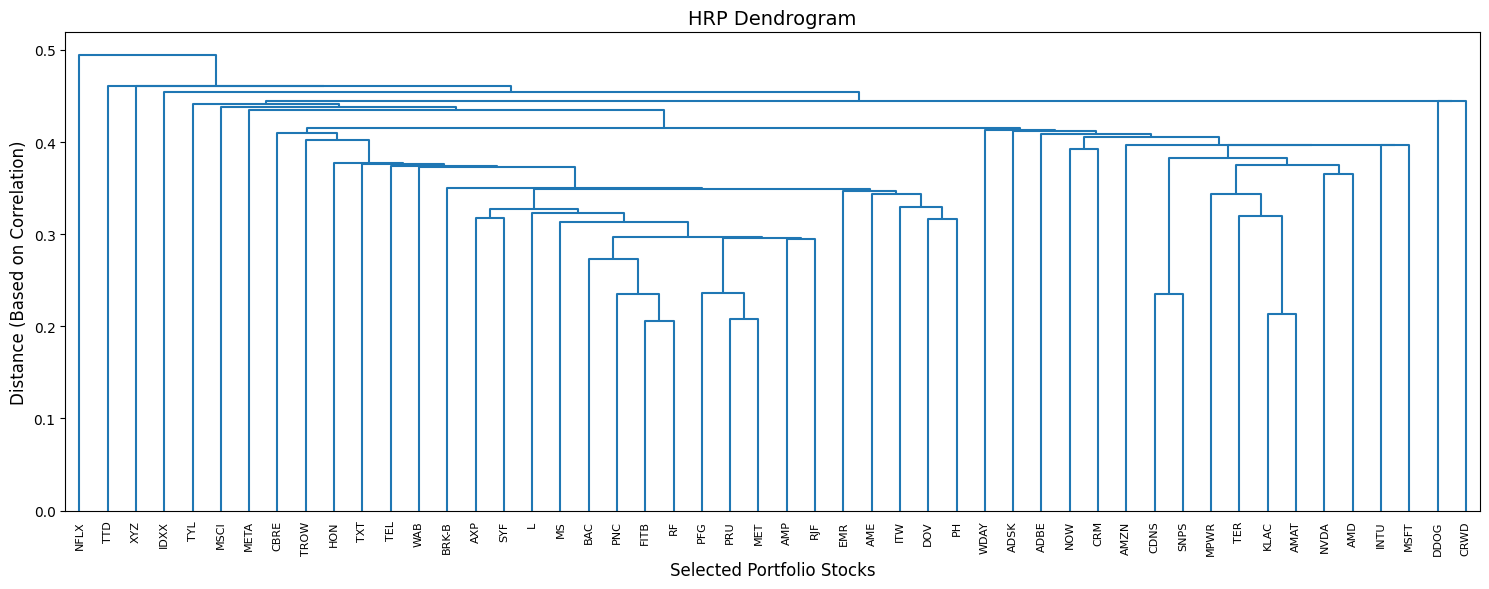

In [15]:
fig, ax = plt.subplots(figsize=(15, 6))
sch.dendrogram(best_link, labels=best_S, ax=ax, leaf_rotation=90, color_threshold=0)
ax.set_title("HRP Dendrogram", fontsize=14)
ax.set_xlabel("Selected Portfolio Stocks", fontsize=12)
ax.set_ylabel("Distance (Based on Correlation)", fontsize=12)
plt.tight_layout()
plt.show()
